# 02 — Risk Measurement, VaR and Expected Shortfall

**Multi-Asset Portfolio Risk and Stress-Testing Framework**

Notebook 01 measured how the portfolios behaved on average. This one measures what
happens in the tail, with three different estimation routes, and takes seriously the
question of *why they disagree*.

> **Disclaimer.** Every portfolio in this notebook is a *hypothetical research construct*
> built from publicly available price data. Nothing here represents a real client account,
> real assets under management, investment advice, or a forecast. Stress scenarios are
> analytical assumptions chosen to probe the portfolio, not predictions about markets.


## Setup

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

from prisk.config import load_config
from prisk import data as dataio, portfolios as pf, metrics as mx
from prisk import risk as rk, stress as stx, backtest as bt, plots
import matplotlib.pyplot as plt

plots.use_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 40)

cfg = load_config()
prices = dataio.load_panel(cfg)
returns = dataio.compute_returns(prices)
holdings = [t for t in cfg.holdings if t in returns.columns]
print(f"{len(prices):,} trading days | {prices.index[0].date()} to {prices.index[-1].date()} | {len(cfg.tickers)} instruments")

results = pf.build_all_portfolios(returns, cfg)
order = ["equal_weight", "minimum_variance", "volatility_target", "benchmark"]
labels = {n: results[n].label for n in order}
market = returns[cfg.market_ticker]
risk_free = dataio.risk_free_daily(returns, cfg)

window = int(cfg.portfolios["estimation_window"])
cov_full = pf.estimate_covariance(returns[holdings], method="ledoit_wolf")
cov_recent = pf.estimate_covariance(returns[holdings].iloc[-window:], method="ledoit_wolf")
PORTFOLIO_VALUE = float(cfg.risk["portfolio_value"])
print(f"notional for currency figures: ${PORTFOLIO_VALUE:,.0f}")

4,855 trading days | 2007-06-01 to 2026-09-17 | 15 instruments


notional for currency figures: $1,000,000


## 1. Is the market risk stable? Rolling beta

A single full-sample beta is an average of regimes. Before trusting it, look at whether
there is a stable number to average.

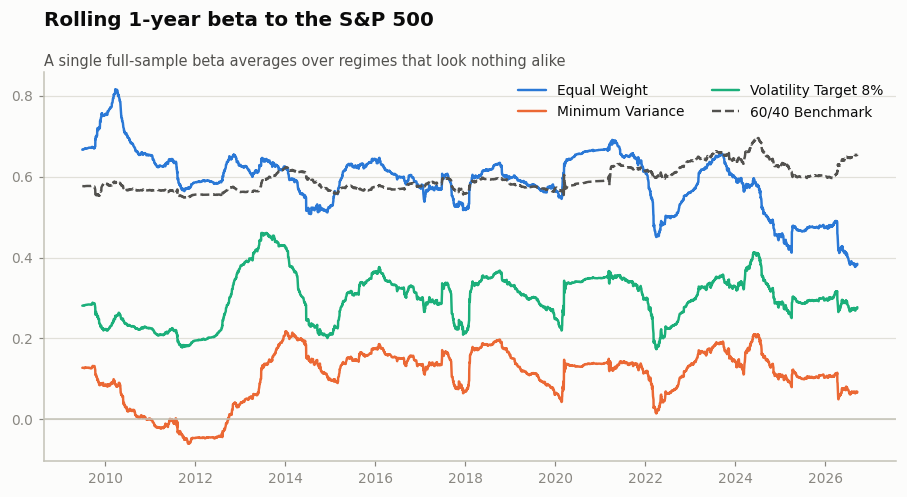

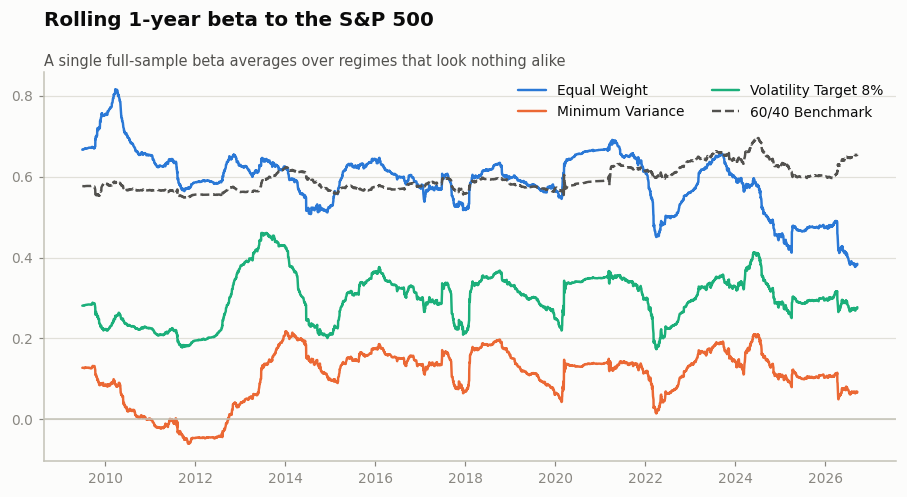

In [2]:
fig, ax = plt.subplots(figsize=(10, 4.6))
for n in order:
    rolling_beta = (results[n].returns.rolling(252).cov(market) /
                    market.rolling(252).var())
    ax.plot(rolling_beta.index, rolling_beta.values,
            color=plots.PORTFOLIO_COLORS[n], label=labels[n],
            linestyle=plots.PORTFOLIO_STYLES[n], linewidth=1.6)
ax.axhline(0, color=plots.BASELINE, linewidth=1)
ax.set_title("Rolling 1-year beta to the S&P 500", color=plots.INK_PRIMARY, pad=30)
ax.text(0.0, 1.015, "A single full-sample beta averages over regimes that look nothing alike",
        transform=ax.transAxes, fontsize=9.5, color=plots.INK_SECONDARY)
ax.legend(ncols=2)
display(fig)

Beta is not a constant for any of these portfolios. The minimum-variance
portfolio in particular swings between near-zero and clearly positive. Any statement of
the form "this portfolio has a beta of 0.11" is a summary, not a property.

## 2. Risk contribution: where the risk actually sits

A weights table tells you where the money went. It does not tell you where the *risk*
went, and the two can look completely different.

For portfolio volatility `σ_p = sqrt(w'Σw)`, Euler's theorem gives an exact additive
decomposition: `σ_p = Σ_i w_i · ∂σ_p/∂w_i`. The component contributions sum to the
portfolio's volatility — not approximately, exactly.

In [3]:
contributions = {n: mx.risk_contributions(results[n].latest_weights(), cov_recent,
                                          cfg.trading_days) for n in order}
table = contributions["equal_weight"]
print(f"components sum to {table['component_contribution'].sum():.6f}")
print(f"portfolio volatility {np.sqrt(results['equal_weight'].latest_weights()[holdings].values @ cov_recent.values @ results['equal_weight'].latest_weights()[holdings].values * 252):.6f}")
display(table.style.format({
    "weight": "{:.2%}", "annualised_volatility": "{:.1%}",
    "marginal_contribution": "{:.3f}", "component_contribution": "{:.2%}",
    "pct_risk_contribution": "{:.1%}"}))

components sum to 0.088453
portfolio volatility 0.088453


,weight,annualised_volatility,marginal_contribution,component_contribution,pct_risk_contribution
ticker,,,,,
AAPL,7.52%,26.8%,0.158,1.19%,13.4%
MSFT,8.49%,26.2%,0.113,0.96%,10.8%
JPM,6.78%,23.0%,0.128,0.87%,9.8%
CAT,4.84%,32.5%,0.175,0.85%,9.6%
XOM,7.70%,23.5%,0.105,0.81%,9.2%
SPY,6.48%,15.3%,0.116,0.75%,8.5%
NEE,5.82%,27.1%,0.127,0.74%,8.3%
VNQ,6.07%,16.8%,0.110,0.67%,7.6%
GLD,6.77%,21.4%,0.080,0.54%,6.1%


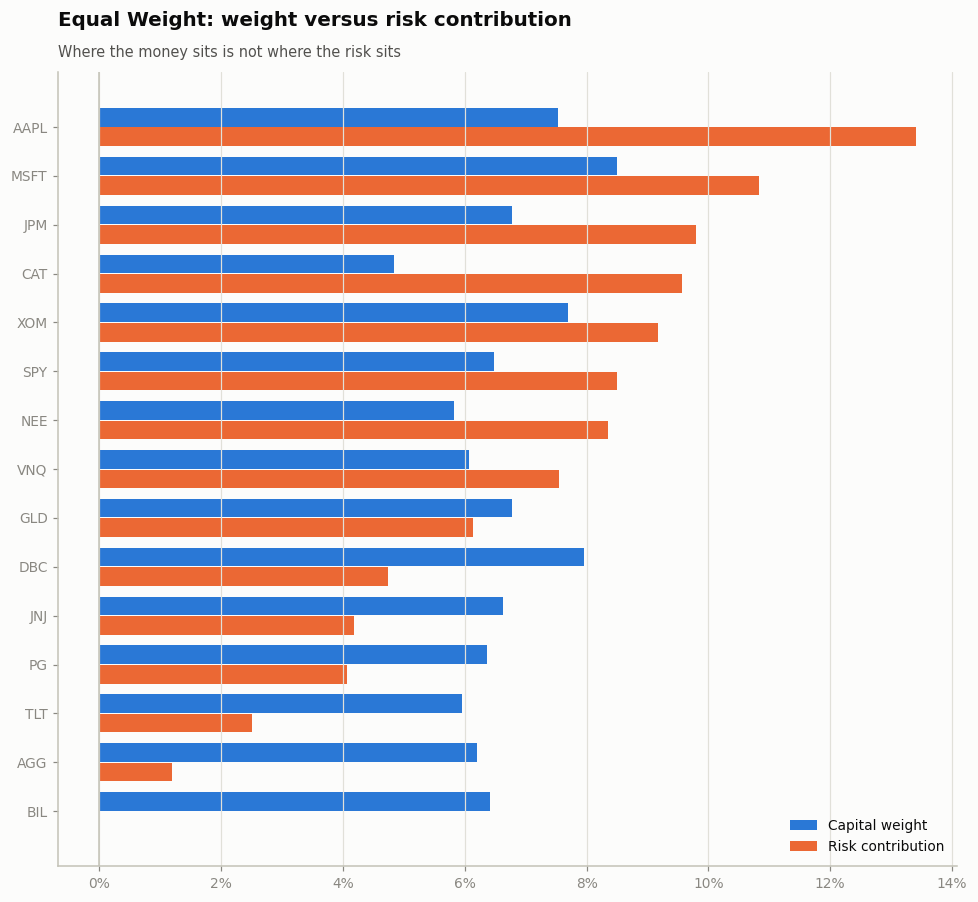

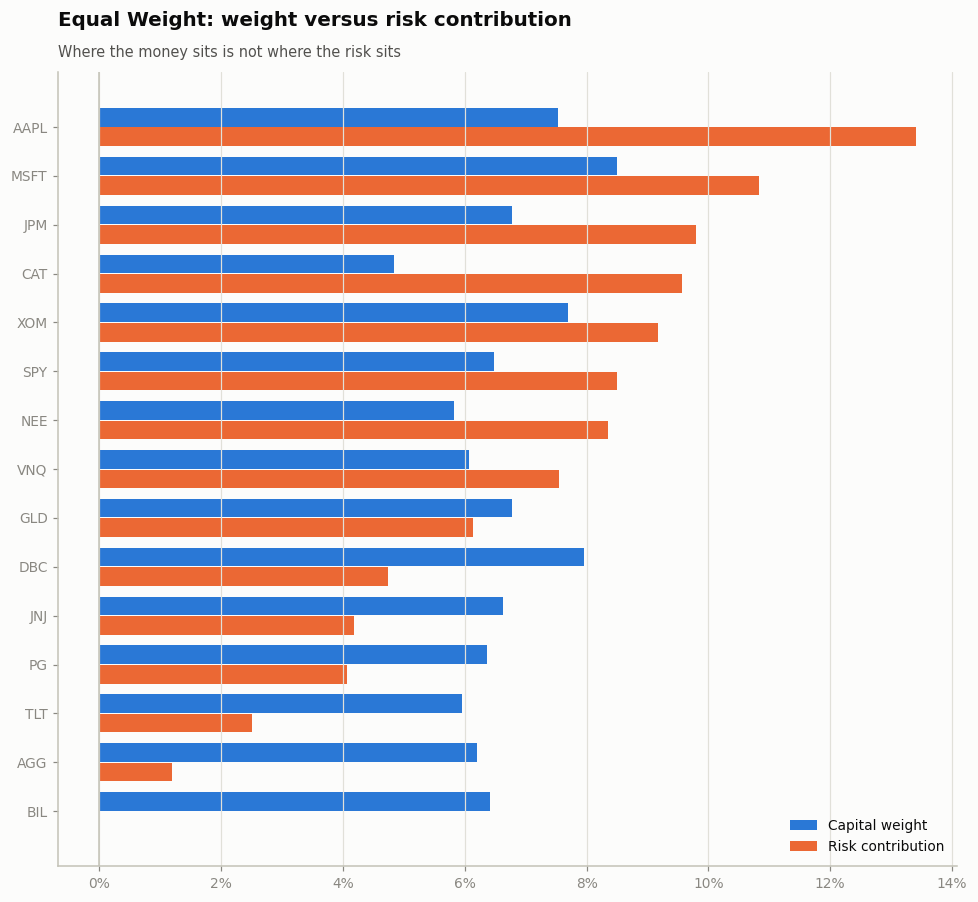

In [4]:
display(plots.plot_risk_contribution(
    contributions["equal_weight"],
    title="Equal Weight: weight versus risk contribution"))

This is the clearest single illustration of why capital weights are not risk
weights. Every holding has the same 6.7% of the capital. Their risk contributions range
from about 14% to essentially zero. The cash sleeve absorbs a fifteenth of the money and
contributes almost nothing to the volatility; the most volatile industrial name absorbs
the same money and contributes more than twice its capital share.

An equal-weighted portfolio is not an equal-risk portfolio. It is not even close.

In [5]:
sleeve_view = pd.concat({
    labels[n]: mx.group_risk_contributions(contributions[n], cfg.sleeve_map())
    for n in order}, names=["portfolio", "sleeve"])
display(sleeve_view.style.format({
    "weight": "{:.1%}", "component_contribution": "{:.2%}",
    "pct_risk_contribution": "{:.1%}", "risk_to_capital_ratio": "{:.2f}"}))

`risk_to_capital_ratio` is the number to read: above 1.0 means the sleeve
consumes more risk budget than capital. It is the diagnostic that turns "we hold 20% in
commodities" into "that 20% is doing 35% of the work".

## 3. The shape of the return distribution

Everything that follows depends on how badly daily returns depart from normal, so measure
it before choosing a method.

In [6]:
shape = pd.DataFrame({labels[n]: mx.distribution_stats(results[n].returns)
                      for n in order}).T
display(shape.style.format({
    "skewness": "{:.2f}", "excess_kurtosis": "{:.1f}",
    "jarque_bera_stat": "{:,.0f}", "jarque_bera_pvalue": "{:.3g}",
    "worst_day": "{:.2%}", "best_day": "{:.2%}", "pct_positive_days": "{:.1%}"}))

,skewness,excess_kurtosis,jarque_bera_stat,jarque_bera_pvalue,worst_day,best_day,pct_positive_days
Equal Weight,-0.11,11.6,"25,693",0,-6.72%,7.83%,55.9%
Minimum Variance,-0.46,10.3,"20,269",0,-3.36%,3.10%,54.7%
Volatility Target 8%,-0.32,19.5,"72,603",0,-5.25%,5.93%,56.4%
60/40 Benchmark,0.08,16.9,"54,461",0,-7.10%,9.93%,55.4%


Excess kurtosis between 10 and 19, and Jarque-Bera p-values indistinguishable
from zero. Normality is rejected overwhelmingly for every portfolio.

To make that concrete: under a normal distribution with the equal-weight portfolio's
volatility, its worst observed day is an event that should occur roughly once in the
lifetime of the universe. It occurred in March 2020.

In [7]:
for n in order:
    r = results[n].returns
    sigma = r.std()
    worst_z = (r.min() - r.mean()) / sigma
    from scipy import stats as sps
    p_normal = sps.norm.cdf(worst_z)
    years = 1 / (p_normal * 252) if p_normal > 0 else float("inf")
    print(f"{labels[n]:<24} worst day {r.min():>7.2%}  = {worst_z:>6.1f} sigma  "
          f"-> once every {years:,.3g} years under normality")

Equal Weight             worst day  -6.72%  =   -8.2 sigma  -> once every 3.89e+13 years under normality
Minimum Variance         worst day  -3.36%  =  -10.5 sigma  -> once every 1.34e+23 years under normality
Volatility Target 8%     worst day  -5.25%  =  -11.3 sigma  -> once every 8.17e+26 years under normality
60/40 Benchmark          worst day  -7.10%  =   -9.6 sigma  -> once every 7.67e+18 years under normality


## 4. Three roads to Value at Risk

**Sign convention.** VaR and ES are reported as positive numbers representing losses. A
1-day 99% VaR of 2.31% means: on 99 days out of 100, the portfolio is not expected to lose
more than 2.31% in a day.

**Historical.** The empirical quantile. Assumes nothing about the distribution, so it
inherits the real fat tails, skew and clustering. Its weaknesses: it can only produce
losses that have already happened, and it weights a 2008 observation exactly like
yesterday's.

**Parametric.** Assumes a distribution and needs only a mean and a variance. Fast,
decomposable, and — under normality — wrong in a known direction for this data. Two
tail-aware variants are included: a fitted Student-t and a Cornish-Fisher expansion that
adjusts the normal quantile for observed skew and kurtosis.

**Monte Carlo.** Simulates from an assumed multivariate process. The most flexible route —
it can price horizons and portfolios with no history — and the most dependent on its
inputs. Here it draws from a multivariate Student-t built as a normal-variance mixture,
which preserves the correlation structure while producing *joint* tail events far more
often than a Gaussian would. Assets crash together; a Gaussian copula does not know
that.

In [8]:
comparison = {}
for n in order:
    comparison[n] = rk.var_comparison(
        results[n].returns, asset_returns=returns[holdings],
        weights=results[n].latest_weights(),
        confidences=[0.95, 0.99], horizons=[1, 10],
        portfolio_value=PORTFOLIO_VALUE,
        mc_kwargs={"n_simulations": 100_000, "distribution": "student_t",
                   "seed": int(cfg.risk["monte_carlo"]["seed"]), "cov": cov_full})
    comparison[n].insert(0, "portfolio", labels[n])

all_var = pd.concat(comparison.values(), ignore_index=True)
one_day = all_var[all_var["horizon_days"] == 1]
display(one_day[[
    "portfolio", "confidence", "historical_var", "parametric_normal_var",
    "parametric_t_var", "cornish_fisher_var", "monte_carlo_var"]]
    .style.format("{:.2%}", subset=[c for c in one_day.columns if c.endswith("_var")])
    .format({"confidence": "{:.0%}"}).hide(axis="index"))

portfolio,confidence,historical_var,parametric_normal_var,parametric_t_var,cornish_fisher_var,monte_carlo_var
Equal Weight,95%,0.011688,0.013074,0.010772,0.011394,0.011007
Equal Weight,99%,0.024457,0.018689,0.023169,0.041642,0.021497
Minimum Variance,95%,0.004710,0.005067,0.004534,0.004805,0.005295
Minimum Variance,99%,0.008452,0.007257,0.008131,0.015792,0.010513
Volatility Target 8%,95%,0.006477,0.007375,0.006123,0.005952,0.009133
Volatility Target 8%,99%,0.012180,0.010554,0.011865,0.032725,0.017933
60/40 Benchmark,95%,0.010775,0.011893,0.009742,0.009175,0.010049
60/40 Benchmark,99%,0.022302,0.016971,0.020824,0.045910,0.019669


**All five methods see the same data.** That matters more than it sounds: if
one method were estimated on a trailing window and another on the full sample, the table
would be measuring the sample, not the method.

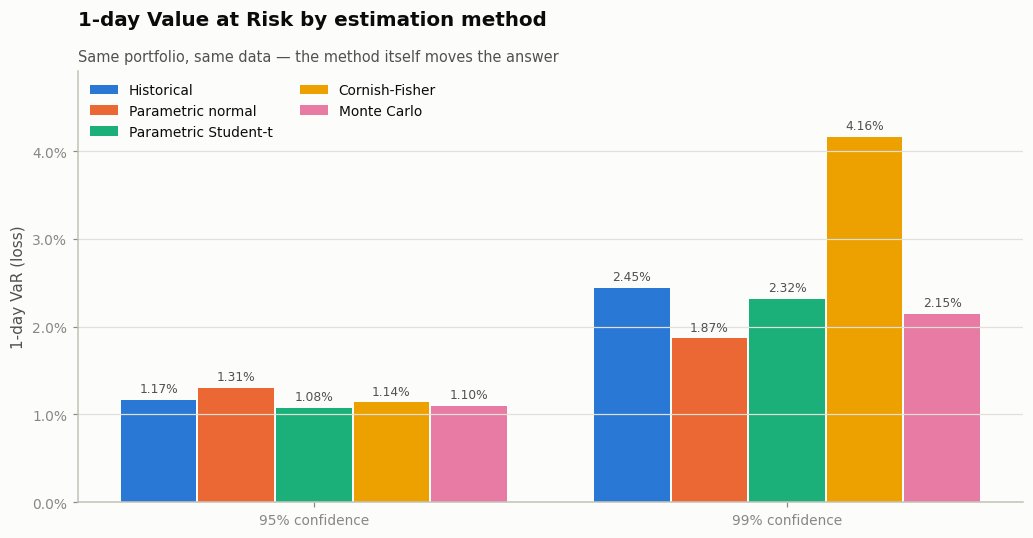

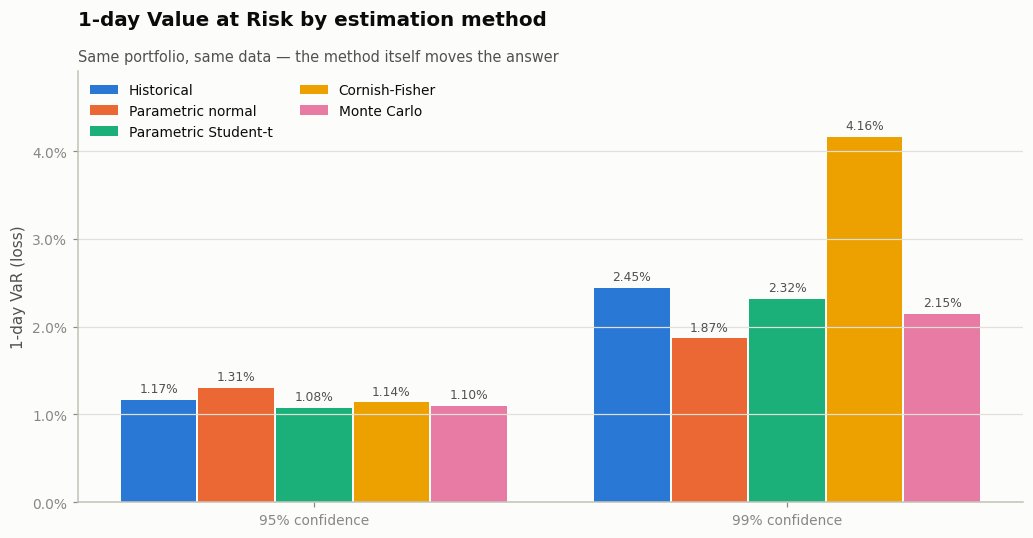

In [9]:
display(plots.plot_var_comparison(comparison["equal_weight"], horizon=1))

### Why they disagree

At **95%** the methods are close, and the Student-t actually sits *below* the normal. That
is not a bug. Standardised for scale, a t distribution has thinner shoulders and a fatter
extreme tail than a normal; the crossover happens somewhere around the 97th-99th
percentile. A t model is not uniformly more conservative — it reallocates probability from
the middle of the tail to the end of it.

At **99%** the ordering inverts and becomes economically meaningful: historical and
Student-t VaR sit well above parametric normal. The normal model understates the 99% loss
by roughly a quarter for the equal-weight portfolio. Over a long enough backtest that gap
shows up as breaches, and notebook 03 counts them.

**Cornish-Fisher is the cautionary tale.** It produces by far the largest numbers — around
4.2% where the historical estimate is 2.5%. That is not conservatism, it is breakdown. The
expansion is a third-order correction valid for *mild* departures from normality; with
excess kurtosis near 12 the correction term dominates and the implied quantile function
stops being monotonic. The honest conclusion is that Cornish-Fisher should not be used on
data this fat-tailed, and the only way to know that is to compute it and look.

## 5. Expected shortfall

VaR answers "how bad is a bad day?" and then stops. It says nothing about what lies beyond
the threshold, and two portfolios with identical VaR can have completely different
behaviour past it.

Expected shortfall is the average loss *conditional on* breaching VaR. It is also a
**coherent** risk measure — in particular it is sub-additive, so combining two portfolios
can never increase it. VaR carries no such guarantee, which is the main theoretical reason
regulators moved towards ES.

In [10]:
es = one_day[["portfolio", "confidence", "historical_var", "historical_es",
                "parametric_normal_es", "parametric_t_es", "monte_carlo_es"]].copy()
es["es_to_var_ratio"] = es["historical_es"] / es["historical_var"]
display(es.style.format("{:.2%}", subset=[c for c in es.columns
                                          if c.endswith(("_var", "_es"))])
        .format({"confidence": "{:.0%}", "es_to_var_ratio": "{:.2f}"}).hide(axis="index"))

portfolio,confidence,historical_var,historical_es,parametric_normal_es,parametric_t_es,monte_carlo_es,es_to_var_ratio
Equal Weight,95%,0.011688,0.019868,0.016517,0.019784,0.018335,1.70
Equal Weight,99%,0.024457,0.035073,0.021482,0.039550,0.033208,1.43
Minimum Variance,95%,0.004710,0.007266,0.006409,0.006912,0.008839,1.54
Minimum Variance,99%,0.008452,0.012244,0.008346,0.011364,0.016049,1.45
Volatility Target 8%,95%,0.006477,0.010712,0.009324,0.010053,0.015206,1.65
Volatility Target 8%,99%,0.012180,0.019723,0.012136,0.017924,0.027545,1.62
60/40 Benchmark,95%,0.010775,0.018043,0.015007,0.017773,0.016694,1.67
60/40 Benchmark,99%,0.022302,0.032147,0.019496,0.035314,0.030109,1.44


The ES/VaR ratio is the tail-shape number. Under a normal distribution at 99% it
is about 1.15. Every portfolio here sits well above that — the average breach is far worse
than the breach threshold. That is what a fat tail *is*, expressed in money.

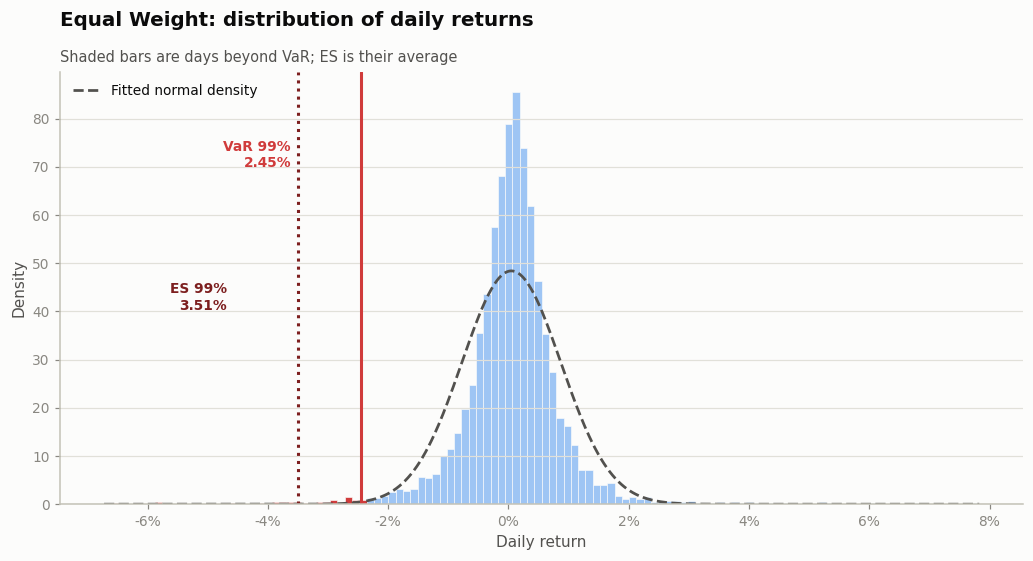

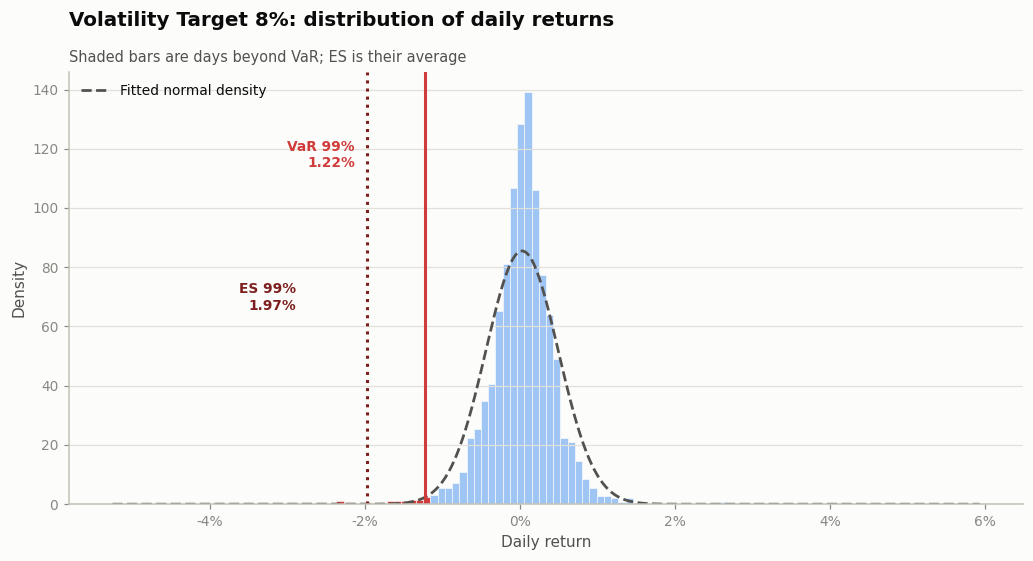

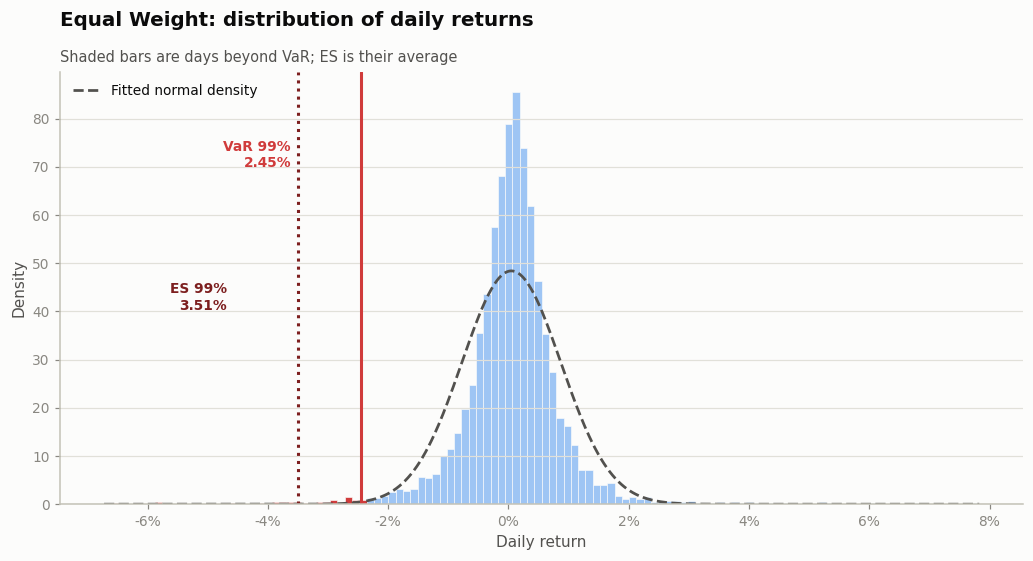

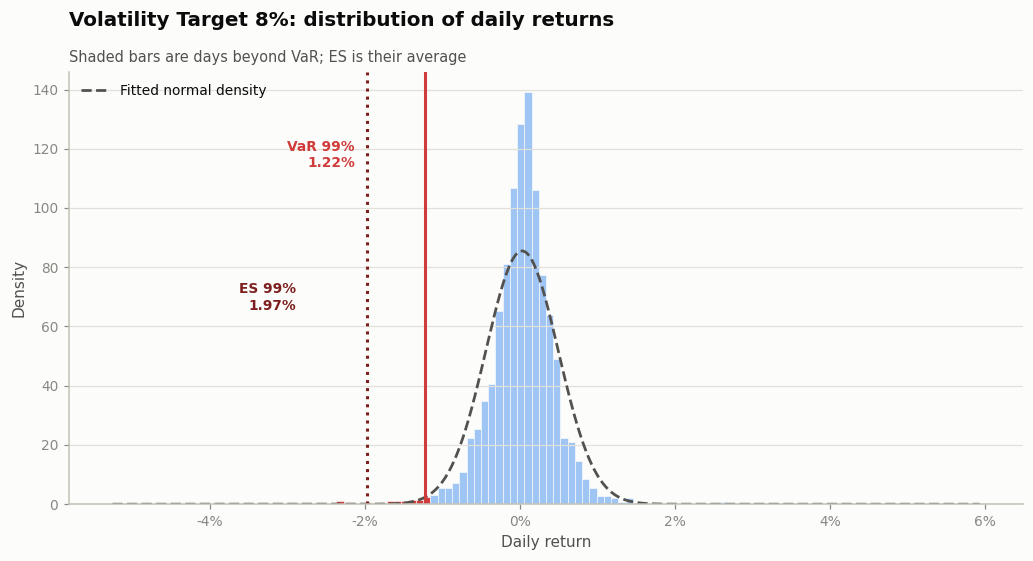

In [11]:
for n in ["equal_weight", "volatility_target"]:
    row = one_day[(one_day["portfolio"] == labels[n]) & (one_day["confidence"] == 0.99)]
    display(plots.plot_return_distribution(
        results[n].returns, var=float(row["historical_var"].iloc[0]),
        expected_shortfall=float(row["historical_es"].iloc[0]),
        confidence=0.99, label=labels[n]))

The gap between the histogram's left tail and the fitted normal curve is the
entire argument against parametric-normal VaR, drawn to scale.

## 6. Monte Carlo in detail

portfolio         : Volatility Target 8%
paths             : 100,000
fitted dof        : 3.00
simulated 10d vol : 0.0226
  95%  VaR   2.99%  ($    29,936)   ES   4.38%
  99%  VaR   4.99%  ($    49,926)   ES   7.00%


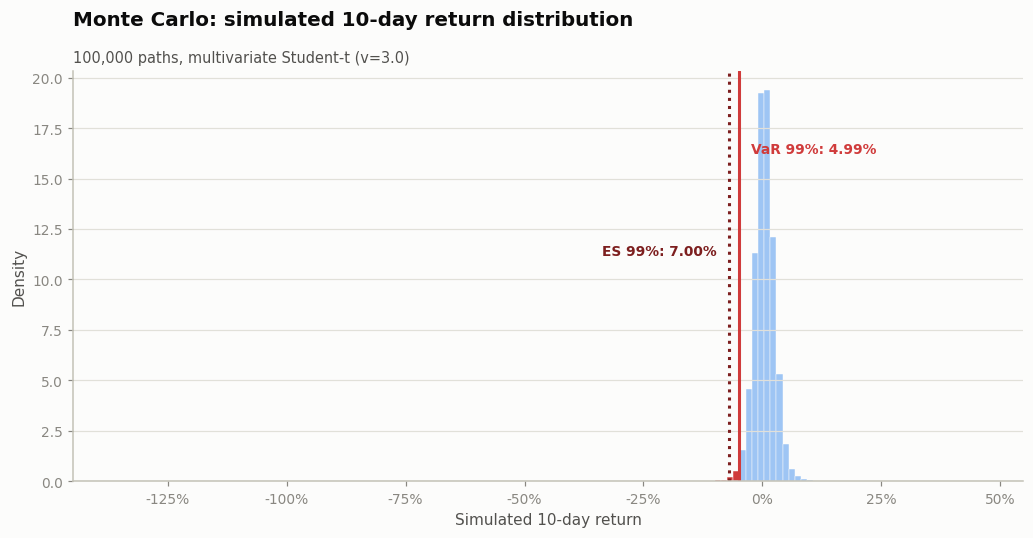

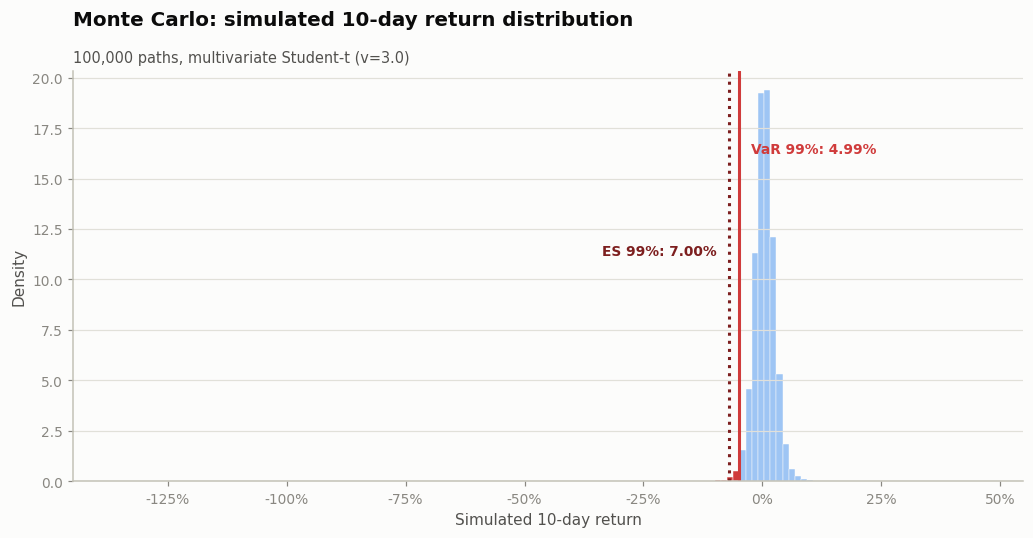

In [12]:
primary = cfg.output["primary_portfolio"]
mc = rk.monte_carlo_var(
    returns[holdings], results[primary].latest_weights(),
    confidences=[0.95, 0.99], horizon=10, n_simulations=100_000,
    distribution="student_t", seed=int(cfg.risk["monte_carlo"]["seed"]), cov=cov_full)

print(f"portfolio         : {labels[primary]}")
print(f"paths             : {mc.n_simulations:,}")
print(f"fitted dof        : {mc.dof:.2f}")
print(f"simulated 10d vol : {mc.simulated_returns.std():.4f}")
for c in [0.95, 0.99]:
    print(f"  {c:.0%}  VaR {mc.var[c]:>7.2%}  (${mc.var[c]*PORTFOLIO_VALUE:>10,.0f})"
          f"   ES {mc.expected_shortfall[c]:>7.2%}")
display(plots.plot_monte_carlo_distribution(
    mc.simulated_returns, mc.var[0.99], mc.expected_shortfall[0.99],
    confidence=0.99, horizon=10,
    n_paths_label=f"{mc.n_simulations:,} paths, multivariate Student-t (v={mc.dof:.1f})"))

**A note on the fitted degrees of freedom.** Maximum likelihood on a long daily
series routinely returns ν below 3, which the implementation floors. That is the estimator
telling you something real: a single Student-t cannot describe nineteen years of daily
returns, because the data is a *mixture* of volatility regimes rather than draws from one
fat-tailed distribution. Below ν = 3 the fourth moment is infinite and the simulated
kurtosis runs into the hundreds — a property of the estimator, not of the portfolio. The
floor is a documented modelling choice, and a GARCH-based simulation would be the
principled next step.

## 7. Component VaR

VaR is homogeneous of degree one in the weights, so Euler's theorem splits it exactly
across assets. These contributions sum to the total — which makes them a genuine budget
that can be managed, not just a ranking.

In [13]:
for n in ["equal_weight", "minimum_variance"]:
    cv = rk.component_var(results[n].latest_weights(), cov_recent, 0.99, 1)
    print(f"\n{labels[n]}   total 1d 99% VaR = {cv['component_var'].sum():.4%}")
    display(cv.head(8).style.format({
        "weight": "{:.2%}", "marginal_var": "{:.4f}",
        "component_var": "{:.3%}", "pct_var_contribution": "{:.1%}"}))


Equal Weight   total 1d 99% VaR = 1.2962%


,weight,marginal_var,component_var,pct_var_contribution
ticker,,,,
AAPL,7.52%,0.0231,0.174%,13.4%
MSFT,8.49%,0.0165,0.140%,10.8%
JPM,6.78%,0.0187,0.127%,9.8%
CAT,4.84%,0.0256,0.124%,9.6%
XOM,7.70%,0.0154,0.119%,9.2%
SPY,6.48%,0.0170,0.110%,8.5%
NEE,5.82%,0.0186,0.108%,8.3%
VNQ,6.07%,0.0161,0.098%,7.6%



Minimum Variance   total 1d 99% VaR = 0.6877%


,weight,marginal_var,component_var,pct_var_contribution
ticker,,,,
DBC,18.98%,0.0138,0.263%,38.2%
MSFT,5.99%,0.0134,0.080%,11.7%
AGG,23.18%,0.0034,0.080%,11.6%
JNJ,7.38%,0.0100,0.074%,10.7%
PG,7.76%,0.0092,0.072%,10.4%
TLT,7.78%,0.0083,0.064%,9.4%
JPM,3.86%,0.0112,0.043%,6.3%
SPY,0.72%,0.0106,0.008%,1.1%


## 8. Risk in the current regime versus the full sample

Every number above uses nineteen years of data, which means it is an *unconditional*
estimate. A risk manager also needs the conditional one: what does this portfolio look
like now?

In [14]:
regime = []
for n in order:
    recent_returns = results[n].returns.iloc[-window:]
    regime.append({
        "portfolio": labels[n],
        "full_sample_vol": mx.annualised_volatility(results[n].returns),
        "recent_vol": mx.annualised_volatility(recent_returns),
        "full_sample_var99": rk.historical_var(results[n].returns, 0.99),
        "recent_var99": rk.historical_var(recent_returns, 0.99),
    })
regime = pd.DataFrame(regime).set_index("portfolio")
regime["var_ratio"] = regime["recent_var99"] / regime["full_sample_var99"]
display(regime.style.format({
    "full_sample_vol": "{:.2%}", "recent_vol": "{:.2%}",
    "full_sample_var99": "{:.2%}", "recent_var99": "{:.2%}", "var_ratio": "{:.2f}"}))

,full_sample_vol,recent_vol,full_sample_var99,recent_var99,var_ratio
portfolio,,,,,
Equal Weight,13.08%,9.08%,2.45%,1.33%,0.54
Minimum Variance,5.10%,4.98%,0.85%,0.75%,0.89
Volatility Target 8%,7.41%,6.97%,1.22%,1.11%,0.91
60/40 Benchmark,11.83%,9.81%,2.23%,1.47%,0.66


Current-regime VaR is materially below the full-sample figure for the risk-on
portfolios. Both numbers are correct and they answer different questions. Reporting only
the trailing-window number during a calm period is how risk systems end up quietly
understating exposure right before it matters — the 2007 problem, in one table.

## Takeaways

1. Beta is not stable for any of these portfolios; a full-sample beta is a summary, not a
   property.
2. Capital weights and risk weights are very different objects. Equal weight is not equal
   risk.
3. Normality is rejected overwhelmingly. Under a normal model, March 2020 was
   astronomically impossible.
4. At 99% the parametric-normal model understates VaR by roughly a quarter relative to the
   historical estimate.
5. Cornish-Fisher breaks down at this level of kurtosis and should not be used here.
6. ES/VaR ratios run well above the normal benchmark of ~1.15: the average breach is much
   worse than the breach threshold.
7. Trailing-window risk currently sits well below the unconditional figure. Both numbers
   are needed.

**Next:** `03_stress_testing_and_backtesting.ipynb` asks whether any of these models
actually works.